# Chapter-11. 动态学习率

## 【章节目标】
- 理解动态学习率的作用
- 熟悉pytorch学习率调整的工作原理
- 熟悉pytorch的学习率调整策略

## 【章节内容】
### 11.1 为什么要调整学习率？
#### 1）为什么要调整学习率？

梯度下降：
$$
w_{i+1} = w_i - \eta \, \nabla L(w_i)
$$

学习率（learning rate）控制更新的步伐  
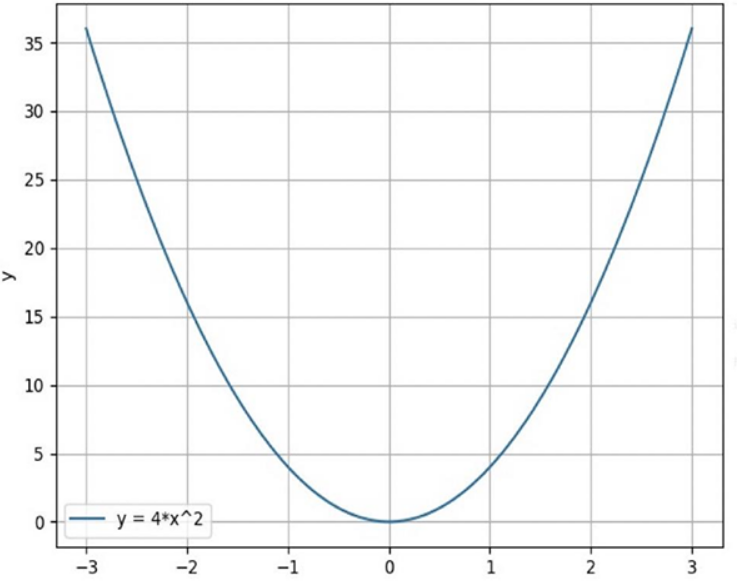  
pytorch中实现了类_LRScheduler，所有学习率调整器都需要继承该类！

**torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch=-1)**

#### 2）_LRScheduler基本属性
- optimizer：关联的优化器

- last_epoch：记录epoch数

- base_lrs：记录初始学习率

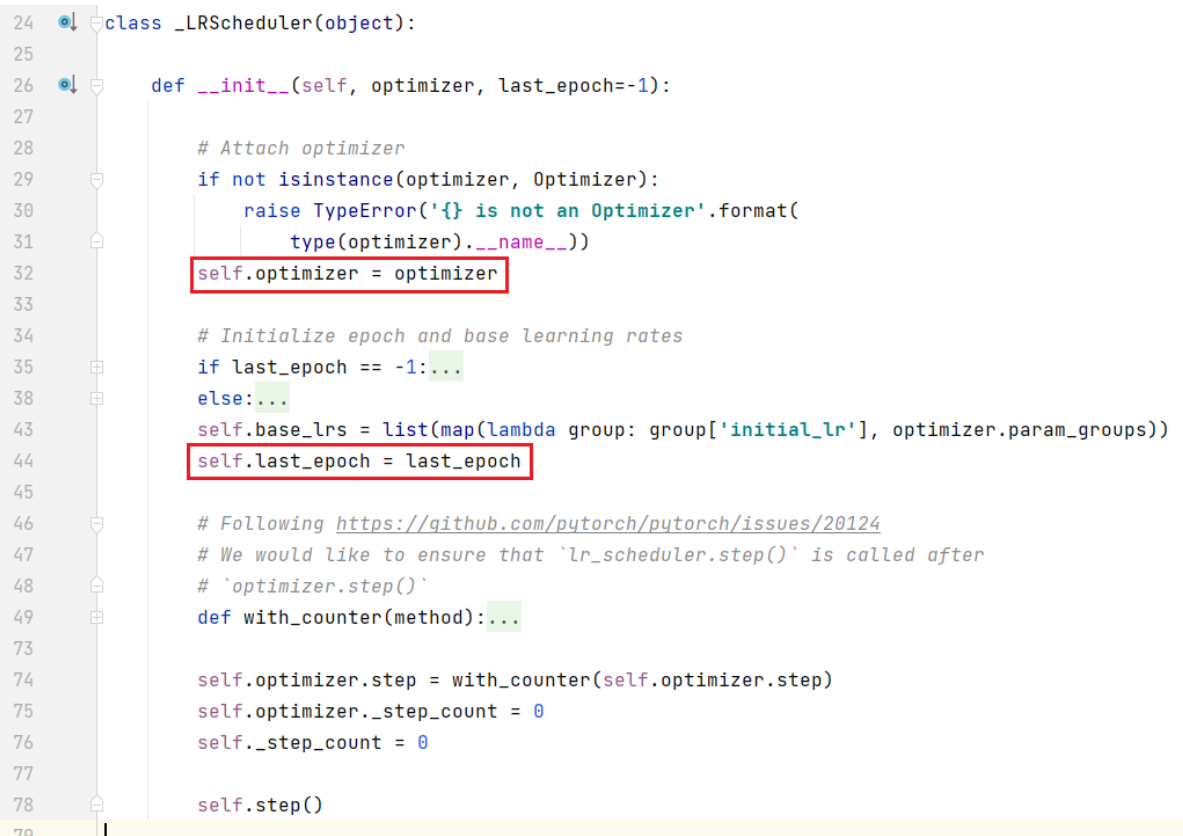

#### 3）_LRScheduler主要方法
- step()：更新下一个epoch的学习率

- get_lr()：虚函数，计算下一个epoch的学习率（需要在子类中实现）

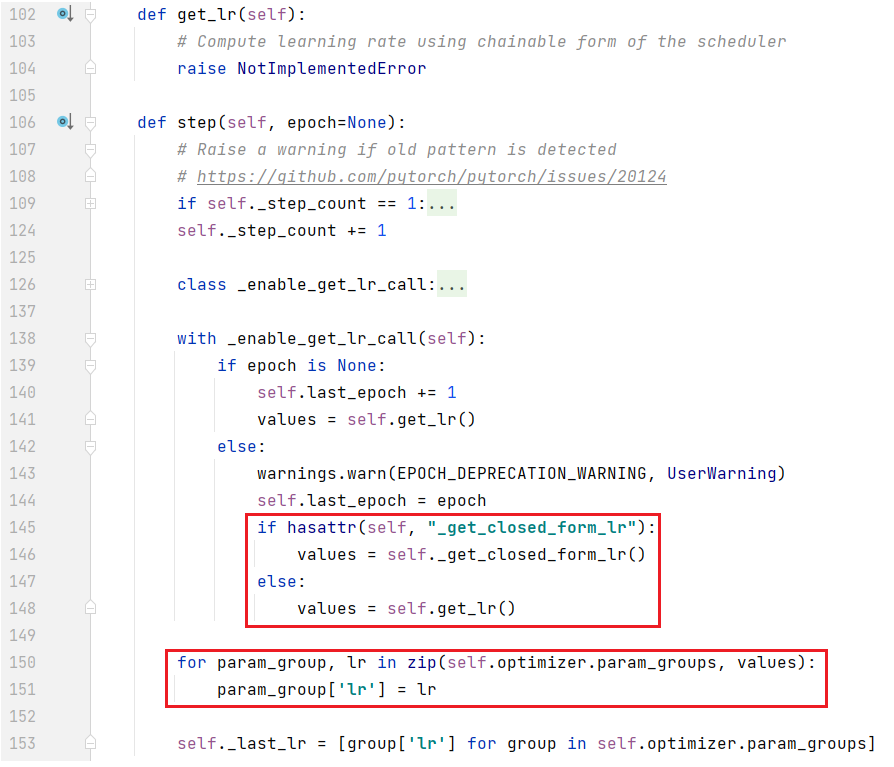

### 11.2 pytorch的六种学习率调整策略
#### 1）StepLR
**torch.optim.lr_scheduler.StepLR(optimizer, step_size, gamma=0.1, last_epoch=-1)**

功能：等间隔调整学习率,每隔一定的epoch，lr会自动乘以gamma

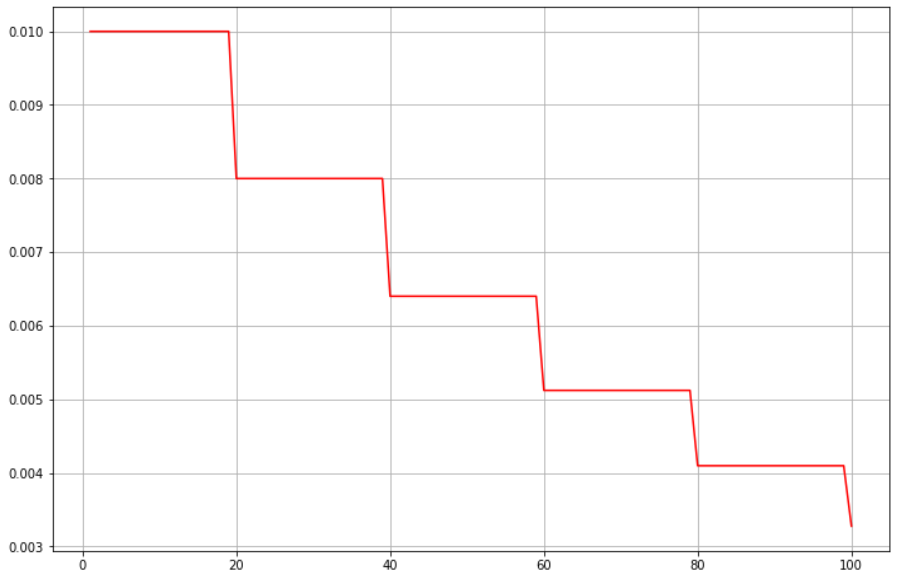

主要参数：

- step_size：调整间隔数
- gamma：调整系数

调整方式：lr = lr * gamma

代码验证：

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11912\117234537.py:23: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step() #这个方法每一个epoch都要调用一次, 但是并不一定修改学习率（满足step_size才修改）


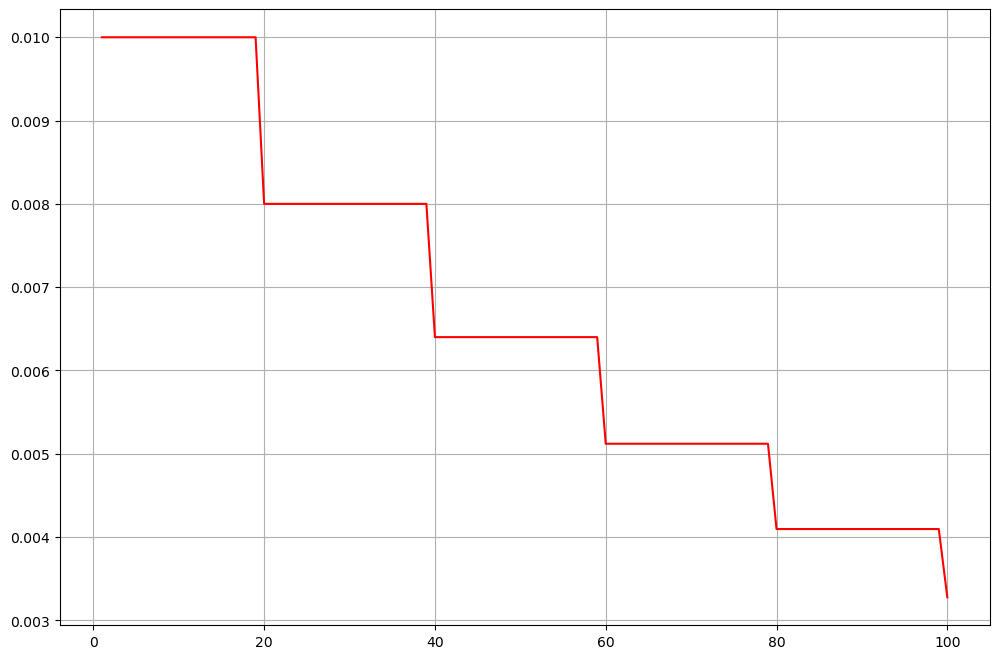

In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from torch.optim import *
import torch.nn as nn
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

#定义一个简单的网络
class net(nn.Module):
    def __init__(self):
        super(net,self).__init__()
        self.fc = nn.Linear(1,10)
    def forward(self,x):
        return self.fc(x)

lr_list = []
model = net()
LR = 0.01
optimizer = Adam(model.parameters(), lr = LR) # 先实例化optimizer
scheduler = lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.8) # 实例化lr_scheduler
for epoch in range(100):
    scheduler.step() #这个方法每一个epoch都要调用一次, 但是并不一定修改学习率（满足step_size才修改）
    lr_list.append(optimizer.state_dict()['param_groups'][0]['lr'])
plt.figure(figsize=(12,8))
plt.plot(range(1,101),lr_list,color = 'r')
plt.grid()
plt.show()

#### 2）MultiStepLR
**torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones, gamma=0.1, last_epoch=-1)**

功能：按给定间隔调整学习率，三段式lr，epoch进入milestones范围内即乘以gamma，离开milestones范围之后再乘以gamma

这种衰减方式也是在学术论文中最常见的方式，一般手动调整也会采用这种方法。

主要参数：

- milestones：设定调整时刻数
- gamma：调整系数

调整方式：lr = lr * gamma

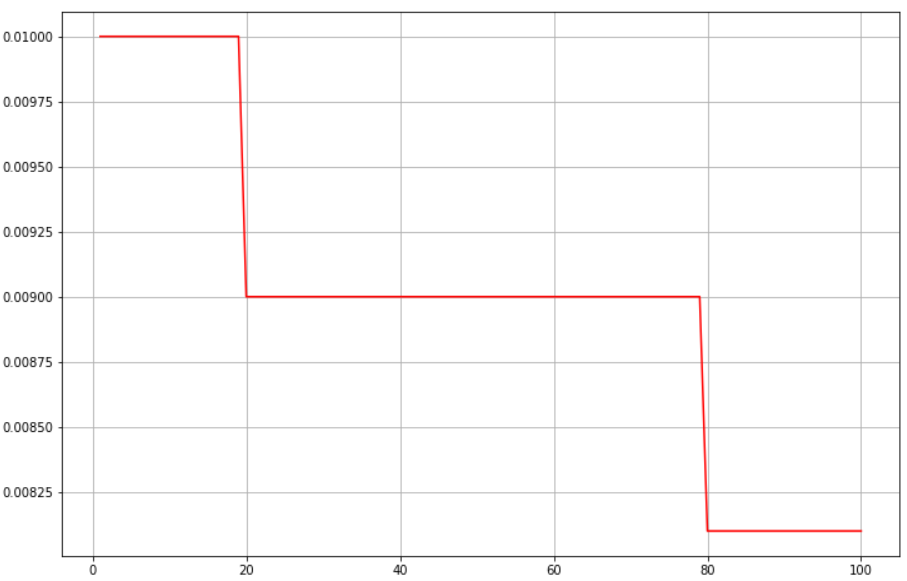

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11912\1303299893.py:7: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


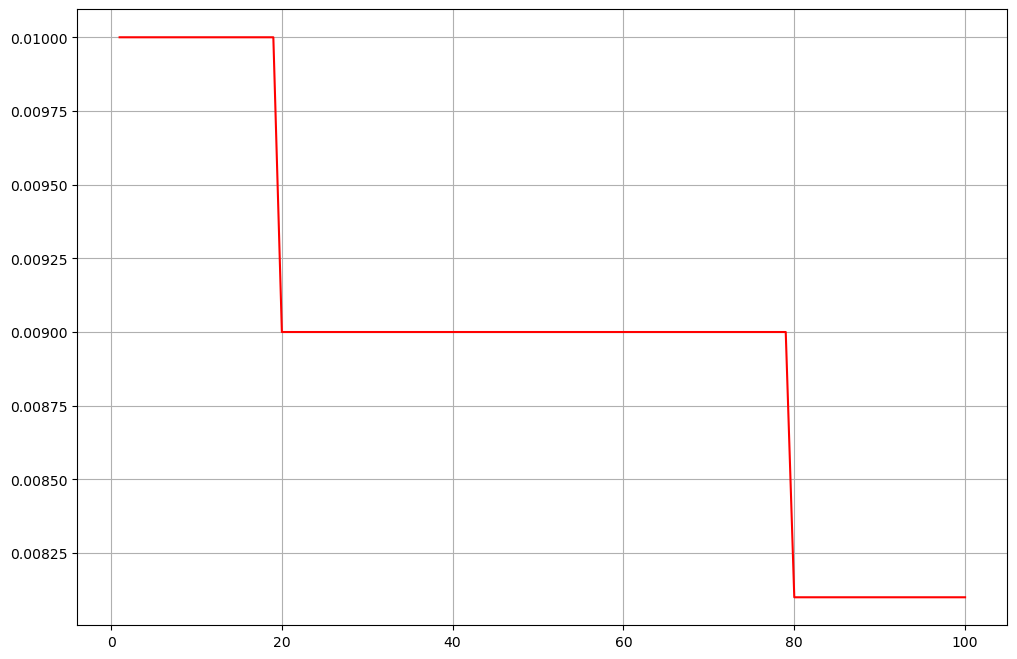

In [3]:
lr_list = []
model = net()
LR = 0.01
optimizer = Adam(model.parameters(),lr = LR)
scheduler = lr_scheduler.MultiStepLR(optimizer, milestones = [20, 80], gamma = 0.9)
for epoch in range(100):
    scheduler.step()
    lr_list.append(optimizer.state_dict()['param_groups'][0]['lr'])
plt.figure(figsize=(12,8))
plt.plot(range(1,101),lr_list,color = 'r')
plt.grid()
plt.show()

#### 3）ExponentialLR
**torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)**

功能：每个epoch按指数衰减调整学习率

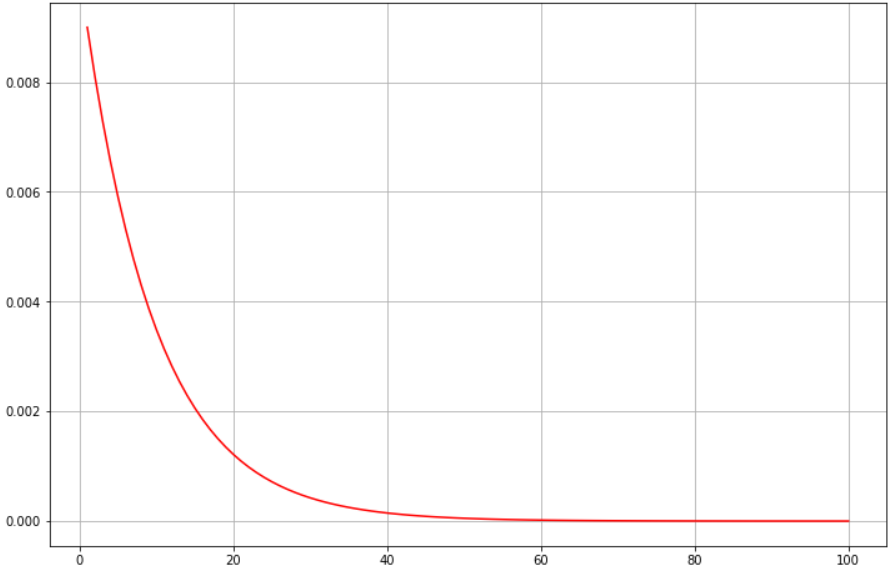

主要参数：  
- gamma：指数的底

调整方式：lr = lr * gamma ** epoch

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11912\3952921807.py:7: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


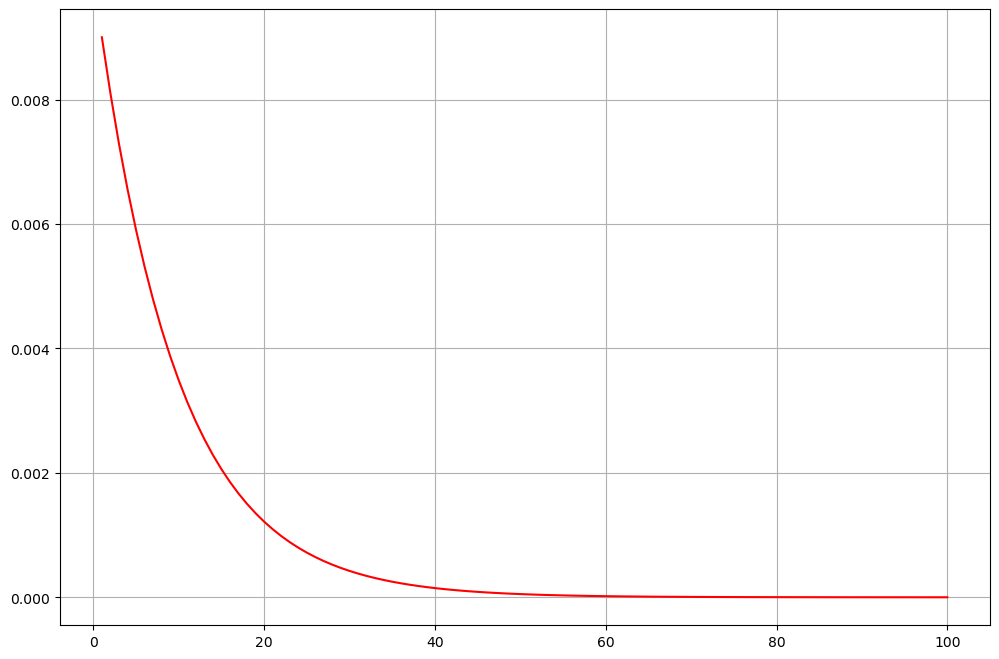

In [4]:
lr_list = []
model = net()
LR = 0.01
optimizer = Adam(model.parameters(),lr = LR)
scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
for epoch in range(100):
    scheduler.step()
    lr_list.append(optimizer.state_dict()['param_groups'][0]['lr'])
plt.figure(figsize=(12,8))
plt.plot(range(1,101),lr_list,color = 'r')
plt.grid()
plt.show()

#### 4）CosineAnnealingLR
**torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max, eta_min=0, last_epoch=-1)**

功能：余弦周期调整学习率

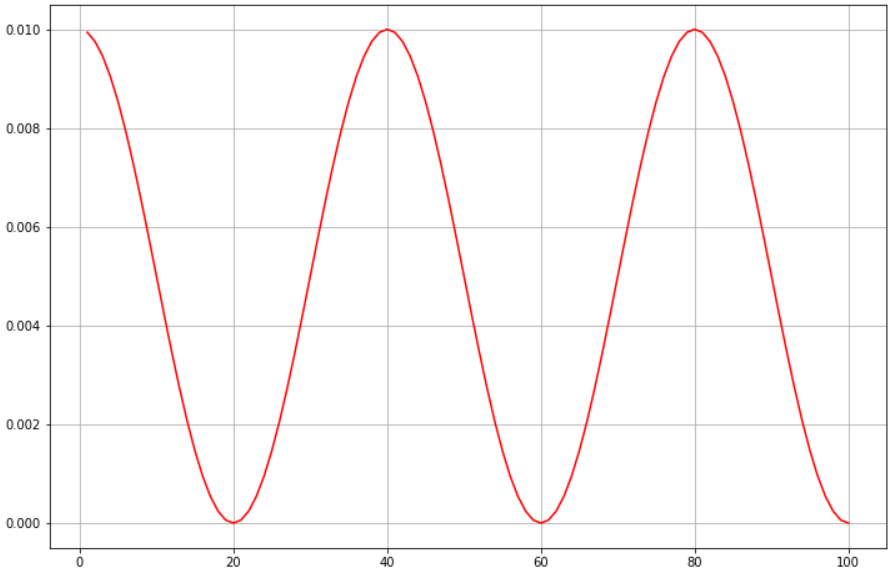

主要参数：

- T_max：下降周期
- eta_min：学习率下限

调整方式：
$$
\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min}) \left( 1 + \cos\left( \frac{T_{\text{cur}}}{T_{\max}} \pi \right) \right)
$$

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11912\1804071869.py:7: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


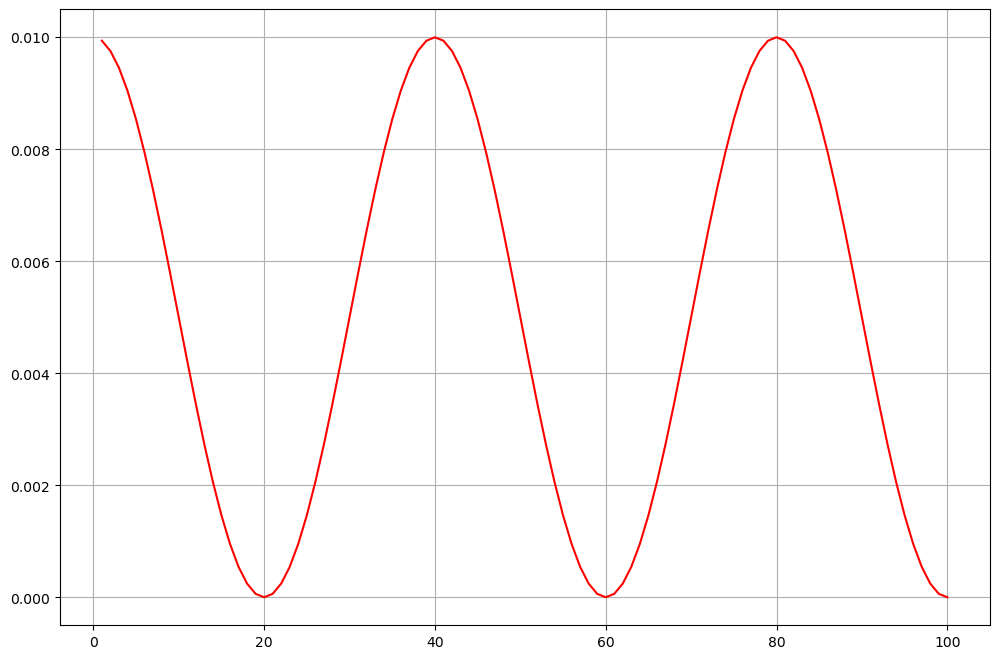

In [5]:
lr_list = []
model = net()
LR = 0.01
optimizer = Adam(model.parameters(),lr = LR)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max = 20)
for epoch in range(100):
    scheduler.step()
    lr_list.append(optimizer.state_dict()['param_groups'][0]['lr'])
plt.figure(figsize=(12,8))
plt.plot(range(1,101),lr_list,color = 'r')
plt.grid()
plt.show()

#### 5）ReduceLROnPlateau(不常用)

In [ ]:
torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                           mode='min',                                  
                                           factor=0.1,                               
                                           patience=10,                                
                                           verbose=False, 
                                           threshold=0.0001, 
                                           threshold_mode='rel', 
                                           cooldown=0, min_lr=0, 
                                           eps=1e-08)

功能：监控指标，当指标不再变化则调整

主要参数：

- mode：min/max 两种模式
- factor：调整系数
- patience：“耐心 ”，接受几次不变化
- cooldown：“冷却时间”，停止监控一段时间
- verbose：是否打印日志
- min_lr：学习率下限
- eps：学习率衰减最小值

#### 6）LambdaLR
**torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch=-1)**

功能：自定义调整策略

主要参数：

- lr_lambda：function or list

lr_lambda函数会接收到一个int参数：epoch，然后根据epoch计算出对应的lr。

如果设置多个lambda函数的话，会分别作用于Optimizer中的不同的params_group

In [ ]:
import numpy as np 
lr_list = []
model = net()
LR = 0.01
optimizer = Adam(model.parameters(),lr = LR)
lambda1 = lambda epoch:np.sin(epoch) / epoch #计算学习率的函数
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda = lambda1)
for epoch in range(100):
    scheduler.step()
    lr_list.append(optimizer.state_dict()['param_groups'][0]['lr'])
plt.figure(figsize=(12,8))
plt.plot(range(1,101),lr_list,color = 'r')
plt.grid()
plt.show()

最后这段代码看出，学习率调整的曲线就是关于epoch的函数，更本质上是关于时间t的函数